In [1]:
import glob, os, re, sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import scienceplots
from classy import Class
from scipy.interpolate import interp1d
plt.style.use(['science', 'no-latex', 'vpedre'])

LINESTYLES = plt.rcParams['axes.prop_cycle'].by_key().get('linestyle', ['-', '--', ':', '-.'])
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

tex_fonts = {
    # Use 10pt or 11pt font to match the document
    "axes.labelsize": 12,
    "font.size": 12,
    # Make the legend/ticks slightly smaller
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

thesis_width = 472.03123

def set_size(width, fraction=1, subplots=(1, 1)):
    """
    Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    -----a-----
    width: float
            Document textwidth in pts
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

fig_dims = set_size(thesis_width)

In [2]:
kk = np.array([1e-3, 1e-2, 1e-1])
_mass = 0.0
base = {
    # 'H0'      : 67,
    # 'Omega_b' : 0.049,
    # 'Omega_cdm': 0.27,
    # 'A_s'     : 2.6e-9,
    # 'n_s'     : 0.96,
    'output'  : 'tCl mPk dTk vTk',
    'k_output_values': ','.join([str(k) for k in kk]),
    'z_max_pk': 5,
    'evolver': 0,
    # # Disable massless neutrinos
    # 'N_ur': 0,
    # # Add 3 massive neutrinos of equal mass
    # 'N_ncdm'  : 1,
    # 'deg_ncdm': 3,
    # 'm_ncdm'  : max(_mass/3, 1e-100),  # avoid exact value of 0.0
    # 'start_small_k_at_tau_c_over_tau_h': 1e-4,
    # 'start_large_k_at_tau_h_over_tau_k': 1e-4,
    # 'perturbations_sampling_stepsize': 0.01,
    # 'l_logstep': 1.026,
    # 'l_linstep': 25,
    # 'k_max_tau0_over_l_max': 8.,
    # 'k_per_decade_for_pk': 200,
    # 'l_max_scalars': 5000,
    # 'P_k_max_h/Mpc': 12.,
    # 'delta_l_max': 1000,
    # 'l_switch_limber': 50
}

def class_w0wa(w0, wa):
    p = dict(base)
    p.update({'Omega_Lambda': 0, 'w0_fld': w0, 'wa_fld': wa, 'cs2_fld': 1.})
    return p

def mochi_w0wa(w0, wa):
    """GR-limit scalar field with CPL expansion history."""
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/gr.dat',
        'parameters_smg': '1e-10',
        'expansion_model': 'w0wa',
        'expansion_smg' : f'0.67, {w0}, {wa}',
        'method_qs_smg' : 'fully_dynamic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p

def mochi_frhs():
    """HS f(R) with CPL expansion history using background-consistent stable_params."""
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/hs_fr_stable_params_fr0_1em4_n_1_mathematica.dat',
        'parameters_smg': '6.061178756035e-5',
        'expansion_model': 'rho_de',
        'expansion_smg' : '0.67',
        'expansion_file_name' : '../stable_params_input/rho_de_stable_hs_fr_n_1_fr0_1em4_mathematica.dat',
        'method_qs_smg' : 'fully_dynamic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p

def mochi_cgal():
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/cubic_galileon_stable_params_mathematica.dat',
        'parameters_smg': '1.380051990990777',
        'expansion_model': 'rho_de',
        'expansion_smg' : '0.67',
        'expansion_file_name' : '../stable_params_input/rho_de_stable_cubic_galileon_mathematica.dat',
        'method_qs_smg' : 'fully_dynamic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p


w0_values = np.array([-1.3, -1.0, -0.7])
wa_values = np.array([-0.6, 0.0, 0.6])

w0_values = np.array([-1.0])
wa_values = np.array([0.0])

W0, Wa = np.meshgrid(w0_values, wa_values)
models_to_run = {}

for w0, wa in zip(W0.ravel(), Wa.ravel()):
    models_to_run[f'lcdm_w0={w0}_wa={wa}']      = class_w0wa(w0, wa)
    models_to_run[f'mochi_lcdm_w0={w0}_wa={wa}'] = mochi_w0wa(w0, wa)
    
models_to_run[f'mochi_frhs'] = mochi_frhs()
models_to_run[f'mochi_cgal'] = mochi_cgal()


In [3]:
cosmo = {}
bk    = {}
pt    = {}

for name, pars in models_to_run.items():
    print(f'Computing {name}...', end=' ', flush=True)
    cosmo[name] = Class()
    cosmo[name].set(pars)
    # try:
    cosmo[name].compute()
    # except:
        # print('problem')
        # continue
    bk[name] = cosmo[name].get_background()
    pt[name] = cosmo[name].get_perturbations()['scalar']
    print('done')

Computing lcdm_w0=-1.0_wa=0.0... done
Computing mochi_lcdm_w0=-1.0_wa=0.0... done
Computing mochi_frhs... done
Computing mochi_cgal... done


In [4]:
rho_frhs = bk['mochi_frhs']['(.)rho_smg']
zz_frhs = bk['mochi_frhs']['z']
aa_frhs = 1/(1+zz_frhs)

rho_cgal = bk['mochi_cgal']['(.)rho_smg']
zz_cgal = bk['mochi_cgal']['z']
aa_cgal = 1/(1+zz_cgal)

rho_lcdm = bk['lcdm_w0=-1.0_wa=0.0']['(.)rho_fld']
zz_lcdm = bk['lcdm_w0=-1.0_wa=0.0']['z']
aa_lcdm = 1/(1+zz_lcdm)

rho_mochi_lcdm = bk['mochi_lcdm_w0=-1.0_wa=0.0']['(.)rho_smg']
zz_mochi_lcdm = bk['mochi_lcdm_w0=-1.0_wa=0.0']['z']
aa_mochi_lcdm = 1/(1+zz_mochi_lcdm)

In [5]:
rho_mochi_lcdm = interp1d(aa_mochi_lcdm, rho_mochi_lcdm)
rho_frhs = interp1d(aa_frhs,       rho_frhs)
rho_cgal = interp1d(aa_cgal,       rho_cgal)

In [6]:
aa = aa_lcdm[aa_lcdm>1e-3]
rho_lcdm = rho_lcdm[aa_lcdm>1e-3]

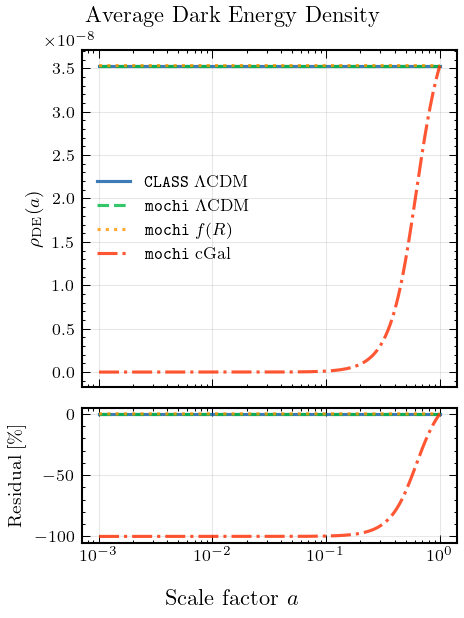

In [7]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(fig_dims[0]*.5, fig_dims[1]*1.2), sharex=True, gridspec_kw={'height_ratios': [3, 1.2]})

ax1.semilogx(aa,           rho_lcdm, alpha=0.8, ls=LINESTYLES[0], label=r'\texttt{CLASS} $\Lambda$CDM')
ax1.semilogx(aa, rho_mochi_lcdm(aa), alpha=0.8, ls=LINESTYLES[1], label=r'\texttt{mochi} $\Lambda$CDM')
ax1.semilogx(aa,       rho_frhs(aa), alpha=0.8, ls=LINESTYLES[2], label=r'\texttt{mochi} $f(R)$')
ax1.semilogx(aa,       rho_cgal(aa), alpha=0.8, ls=LINESTYLES[3], label=r'\texttt{mochi} cGal')

ax2.semilogx(aa, 100*(rho_lcdm/rho_lcdm-1)          , alpha=0.8, ls=LINESTYLES[0])
ax2.semilogx(aa, 100*(rho_mochi_lcdm(aa)/rho_lcdm-1), alpha=0.8, ls=LINESTYLES[1])
ax2.semilogx(aa, 100*(      rho_frhs(aa)/rho_lcdm-1), alpha=0.8, ls=LINESTYLES[2])
ax2.semilogx(aa, 100*(      rho_cgal(aa)/rho_lcdm-1), alpha=0.8, ls=LINESTYLES[3])

ax1.yaxis.get_offset_text().set_x(-0.1) # Adjust this number as needed
ax1.set_ylabel(r'$\rho_{\rm DE}(a)$')
ax2.set_ylabel(r'Residual [\%]')
fig.suptitle('Average Dark Energy Density', y=0.9)
fig.supxlabel('Scale factor $a$', y=0.07)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
ax1.legend()
fig.savefig('../imgs/background_DE.pdf')

In [8]:
def plot_de_pert(pert_key, k_idx=0, skip='black'):
    fig, ax = plt.subplots()

    for model in models_to_run.keys():
        if skip in model:
            continue
        if 'mochi' in model:
            aa      = pt[model][k_idx]['a']
            pert    = pt[model][k_idx][f'{pert_key}_smg']#/pt[model][k_idx][f'{pert_key}_smg'][-1]
            label=model
        else:
            aa      = pt[model][k_idx]['a']
            try:
                pert    = pt[model][k_idx][f'{pert_key}_fld']#/pt[model][k_idx][f'{pert_key}_fld'][-1]
            except:
                pert = np.zeros_like(aa)
            label='lcdm'
        ax.semilogx(aa, pert, label=label)
        ax.set_title(pert_key)
    ax.legend()


def plot_de(k_list=kk, skip='None'):
    fig, axes = plt.subplots(len(k_list), 3, figsize=(fig_dims[0]*1.5*0.68, fig_dims[1]*1.9*0.68), sharex=True)
    for k_idx, k in enumerate(k_list):
        for model in models_to_run.keys():
            ax_row = axes[k_idx]
            d = pt[model][k_idx]
            if skip in model:
                continue
            if 'mochi' not in model:
                aa = d['a']
                try:
                    delta   = d['delta_fld']
                    theta   = d['theta_fld']
                    shear   = d['shear_fld']
                except:
                    delta = np.zeros_like(aa)
                    theta = np.zeros_like(aa)
                    shear = np.zeros_like(aa)
                label = r'\texttt{CLASS} $\Lambda$CDM'
                ls=LINESTYLES[0]
            else:
                aa      = d['a']
                delta   = d['delta_smg']
                theta   = d['theta_smg']
                shear   = d['shear_smg']
                lbl = model.split('_')[1]
                if lbl == 'lcdm':
                    label = r'\texttt{mochi} $\Lambda$CDM'
                    ls=LINESTYLES[1]
                elif lbl == 'frhs':
                    label = r'\texttt{mochi} $f(R)$ HS'
                    ls=LINESTYLES[2]
                else:
                    label = r'\texttt{mochi} cGalileon'
                    ls=LINESTYLES[3]

            ax_row[0].semilogx(aa, delta, label=label, ls=ls)
            ax_row[1].semilogx(aa, theta, label=label, ls=ls)
            ax_row[2].semilogx(aa, shear, label=label, ls=ls)
            
            ax_row[0].set_ylabel(rf'$k={k}$ ' r'Mpc$^{-1}$')

    axes[0][0].set_title(r'$\delta_{\rm DE}(a)$')
    axes[0][1].set_title(r'$\theta_{\rm DE}(a)$')
    axes[0][2].set_title(r'$\sigma_{\rm DE}(a)$')
    axes[0][2].legend()
    plt.tight_layout()
    fig.suptitle(r'Evolution of Dark Energy Perturbations', y=1.01)
    fig.supxlabel('Scale factor $a$', y=-0.01)
    fig.savefig('../imgs/de_perturbations.pdf')

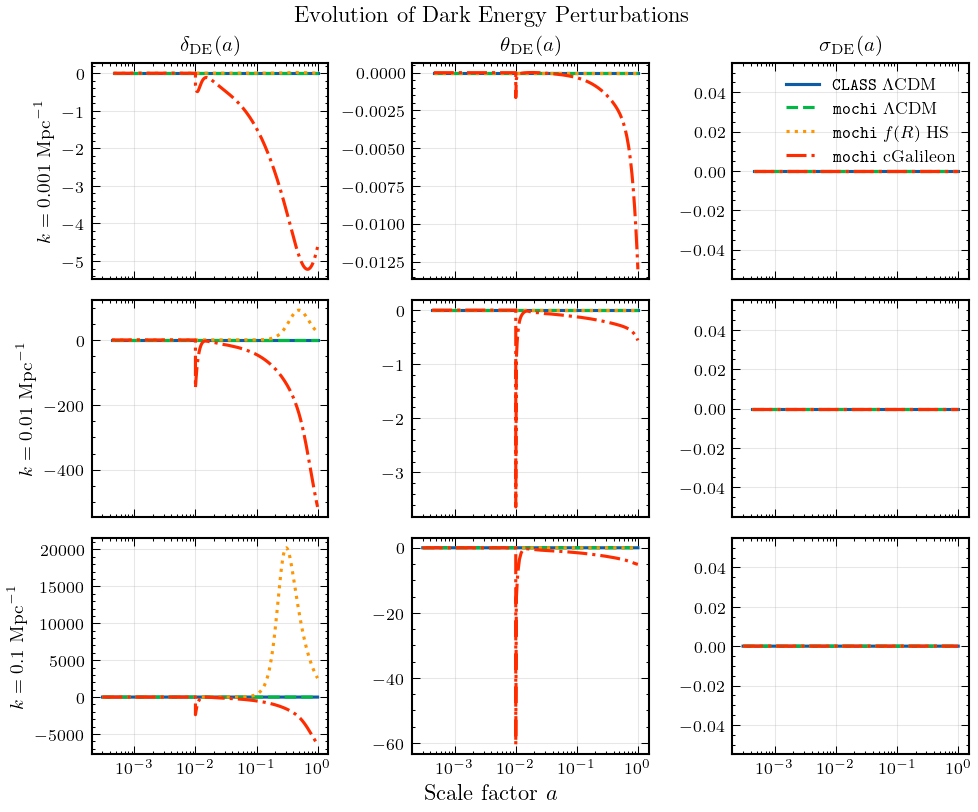

In [9]:
plot_de()

In [10]:
k_arr = np.logspace(-4, 0, 500)  # k in 1/Mpc

Pk = {}
for name in models_to_run.keys():
    Pk[name] = np.array([cosmo[name].pk_lin(k, 0.0) for k in k_arr])

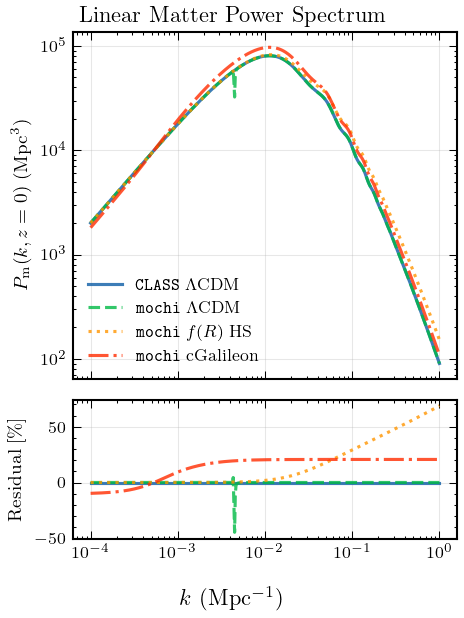

In [11]:
lcdm_ref = 'lcdm_w0=-1.0_wa=0.0'

model_labels = {
    'lcdm_w0=-1.0_wa=0.0'       : r'\texttt{CLASS} $\Lambda$CDM',
    'mochi_lcdm_w0=-1.0_wa=0.0' : r'\texttt{mochi} $\Lambda$CDM',
    'mochi_frhs'                 : r'\texttt{mochi} $f(R)$ HS',
    'mochi_cgal'                 : r'\texttt{mochi} cGalileon',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_dims[0]*.5, fig_dims[1]*1.2), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2]})

for i, (name, label) in enumerate(model_labels.items()):
    ax1.loglog(k_arr, Pk[name], alpha=0.8, ls=LINESTYLES[i], label=label)
    ax2.semilogx(k_arr, 100*(Pk[name]/Pk[lcdm_ref]-1), alpha=0.8, ls=LINESTYLES[i])

ax1.set_ylabel(r'$P_{\rm m}(k,z=0)$ (Mpc$^3$)')
ax2.set_ylabel(r'Residual [\%]')
fig.suptitle(r'Linear Matter Power Spectrum', y=0.9)
fig.supxlabel(r'$k$ (Mpc$^{-1}$)', y=0.07)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
ax1.legend()
fig.savefig('../imgs/matter_power_spectrum.pdf')

In [12]:
from matplotlib.lines import Line2D

k_arr = np.logspace(-2, 0, 500)  # k in 1/Mpc

Pk = {}
for name in models_to_run.keys():
    Pk[name] = np.array([cosmo[name].pk_lin(k, 0.0) for k in k_arr])

MODEL_LABEL_2 = {
    'lambda_concept': r'$\Lambda\mathrm{CDM}$',
    'lambda_mochi':   r'$\Lambda\mathrm{CDM}$',
    'frhs_mochi':     r'$f(R)$ Hu-Sawicki',
    'cgal_mochi':     r'$\mathrm{Cubic Galileon}$',
}
MODEL_ORDER = ['lambda_concept', 'lambda_mochi', 'frhs_mochi', 'cgal_mochi']
model_colors = {m: COLORS[i] for i, m in enumerate(MODEL_ORDER)}

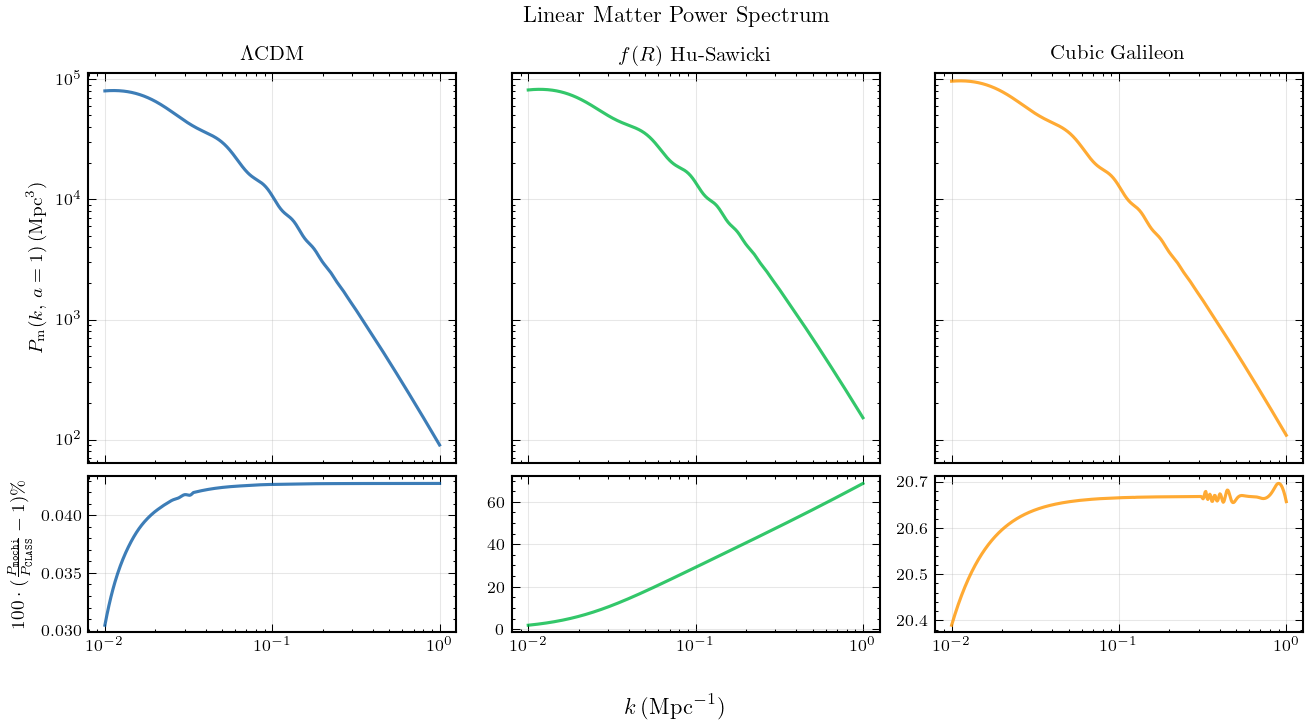

In [13]:
lcdm_ref = 'lcdm_w0=-1.0_wa=0.0'

model_labels = {
    # 'lcdm_w0=-1.0_wa=0.0'       : r'\texttt{CLASS} $\Lambda$CDM',
    'mochi_lcdm_w0=-1.0_wa=0.0' : r'$\Lambda$CDM',
    'mochi_frhs'                : r'$f(R)$ Hu-Sawicki',
    'mochi_cgal'                : r'Cubic Galileon',
}

fig, (ax1, ax2) = plt.subplots(2, 3, figsize=(fig_dims[0]*2*.8, fig_dims[1]*1.5*.8), 
                               sharex=True,
                               gridspec_kw={'height_ratios': [3, 1.2]})
fig.subplots_adjust(hspace=0.05, wspace=0.15)

for idx, (name, label) in enumerate(model_labels.items()):
    color = model_colors.get(name, 'k')
    ax1[idx].loglog(k_arr, Pk[name], alpha=0.8, label=label, color=COLORS[idx])
    ax2[idx].semilogx(k_arr, 100*(Pk[name]/Pk[lcdm_ref]-1), alpha=0.8, color=COLORS[idx])
    ax1[idx].set_title(label, fontsize=10)

# Manually share the Y-axis for the upper panel (ax1) only
ax1[1].sharey(ax1[0])
ax1[2].sharey(ax1[0])

# Hide the Y-tick labels on the shared upper axes so they don't clutter the plot
plt.setp(ax1[1].get_yticklabels(), visible=False)
plt.setp(ax1[2].get_yticklabels(), visible=False)

# Set Y-axis labels only on the first column (thanks to sharey='row')
ax1[0].set_ylabel(r'$P_{\rm m}(k,\,a=1)\,(\mathrm{Mpc}^3)$')
ax2[0].set_ylabel(r'$100\cdot(\frac{P_{\texttt{mochi}}}{P_{\texttt{CLASS}}}-1)\%$') 
fig.supxlabel(r'$k\,(\mathrm{Mpc}^{-1})$', y=-0.01)

fig.suptitle(r'Linear Matter Power Spectrum', y=0.97)
fig.savefig('linear_powerspec.pdf', bbox_inches='tight')


Plotting H_T_prime

In [14]:
lcdm_ref = 'lcdm_w0=-1.0_wa=0.0'

model_labels = {
    'lcdm_w0=-1.0_wa=0.0'       : r'\texttt{CLASS} $\Lambda$CDM',
    'mochi_lcdm_w0=-1.0_wa=0.0' : r'$\Lambda$CDM',
    'mochi_frhs'                : r'$f(R)$ Hu-Sawicki',
    'mochi_cgal'                : r'Cubic Galileon',
}

In [15]:
model_labels.items()

dict_items([('lcdm_w0=-1.0_wa=0.0', '\\texttt{CLASS} $\\Lambda$CDM'), ('mochi_lcdm_w0=-1.0_wa=0.0', '$\\Lambda$CDM'), ('mochi_frhs', '$f(R)$ Hu-Sawicki'), ('mochi_cgal', 'Cubic Galileon')])

In [16]:
pt['lcdm_w0=-1.0_wa=0.0'][0].keys()

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_rho_fld', 'rho_plus_p_theta_fld', 'delta_p_fld', 'delta_fld', 'theta_fld', 'cs2_fld', 'theta_tot', 'H_T_prime', 'h_prime', 'h_prime_prime', 'eta', 'eta_prime', 'alpha', 'alpha_prime', 'einstein00'])

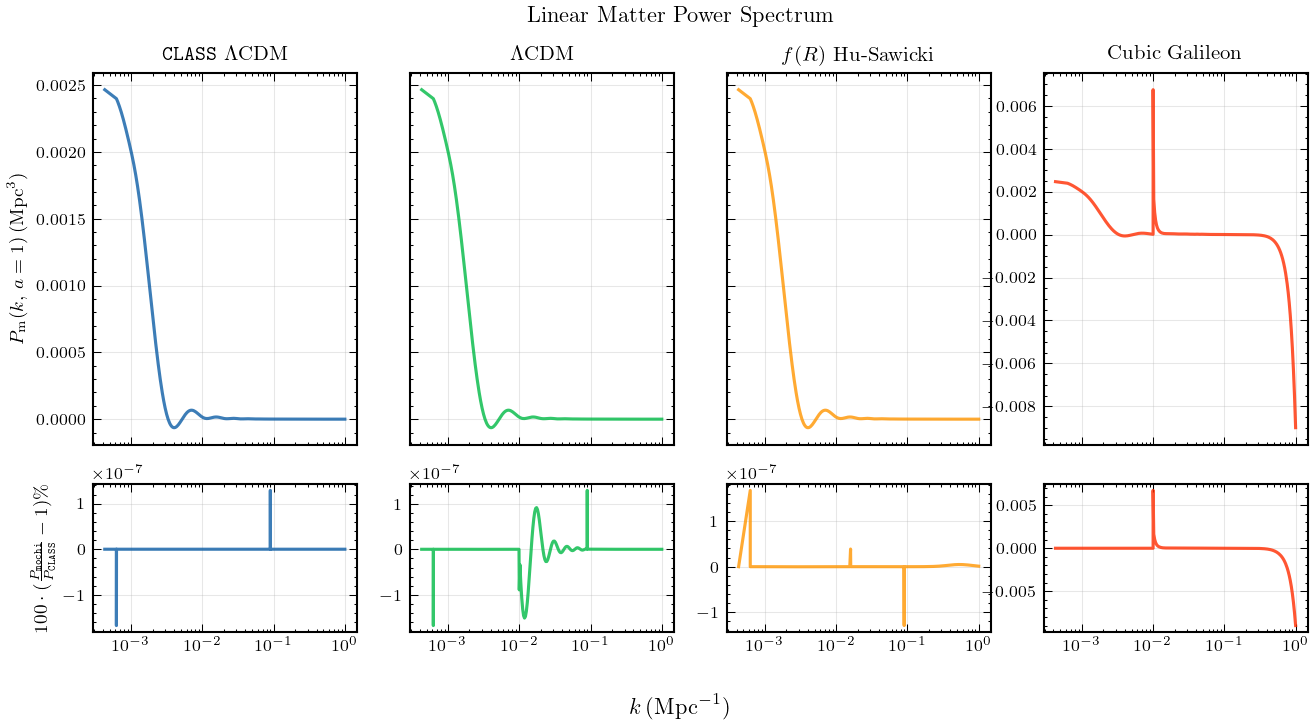

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 4, figsize=(fig_dims[0]*2*.8, fig_dims[1]*1.5*.8), 
                               sharex=True,
                               gridspec_kw={'height_ratios': [3, 1.2]})
fig.subplots_adjust(hspace=0.15)

for idx, (model, label) in enumerate(model_labels.items()):
    k_idx = 1
    k = kk[k_idx]

    color = model_colors.get(name, 'k')
    d = pt[model][k_idx]
    H_T_prime = d['H_T_prime']
    a = d['a']
    H_T_prime_ref = pt['lcdm_w0=-1.0_wa=0.0'][k_idx]['H_T_prime']
    a_ref = pt['lcdm_w0=-1.0_wa=0.0'][k_idx]['a']
    # mask = a > a_ref.min()
    # a = a[mask]
    # H_T_prime = H_T_prime[mask]
    H_T_prime_ref_int = interp1d(a_ref, H_T_prime_ref, fill_value='extrapolate')
    ax1[idx].semilogx(a, H_T_prime, alpha=0.8, label=label, color=COLORS[idx])
    # ax2[idx].semilogx(a, 100*(H_T_prime/H_T_prime_ref_int(a)-1), alpha=0.8, color=COLORS[idx])
    ax2[idx].semilogx(a, (H_T_prime-H_T_prime_ref_int(a)), alpha=0.8, color=COLORS[idx])
    ax1[idx].set_title(label, fontsize=10)

# Manually share the Y-axis for the upper panel (ax1) only
ax1[1].sharey(ax1[0])
ax1[2].sharey(ax1[0])

# Hide the Y-tick labels on the shared upper axes so they don't clutter the plot
plt.setp(ax1[1].get_yticklabels(), visible=False)
plt.setp(ax1[2].get_yticklabels(), visible=False)

# Set Y-axis labels only on the first column (thanks to sharey='row')
ax1[0].set_ylabel(r'$P_{\rm m}(k,\,a=1)\,(\mathrm{Mpc}^3)$')
ax2[0].set_ylabel(r'$100\cdot(\frac{P_{\texttt{mochi}}}{P_{\texttt{CLASS}}}-1)\%$') 
fig.supxlabel(r'$k\,(\mathrm{Mpc}^{-1})$', y=-0.01)

fig.suptitle(r'Linear Matter Power Spectrum', y=0.97)
fig.savefig('linear_powerspec.pdf', bbox_inches='tight')
